In [1]:
# -*- coding: utf-8 -*-
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#    http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or
# implied.
# See the License for the specific language governing permissions and
# limitations under the License.
#

# Time-series forecasting with Deep Learning

#### Instalation `pip install mpld3 pydot`
`mpld3` enables zooming of the matplotlib and interactive data visualizations on Jupyter notebook.

In [2]:
import numpy as np
import pandas as pd
# import pandas_datareader as pdr
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import pyplot
%matplotlib inline
matplotlib.style.use('ggplot')

import seaborn as sns
sns.set(context='paper', style='whitegrid', color_codes=True)   
sns.set_palette(sns.color_palette(["#017b92", "#f97306", "#ff0000"]))  # ["green", "orange", "red"] 

# import mpld3
# mpld3.enable_notebook()

In [3]:
# get all targets y from a TimeseriesGenerator instance.
def get_y_from_generator(gen):
    y = None
    for i in range(len(gen)):
        batch_y = gen[i][1]
        if y is None:
            y = batch_y
        else:
            y = np.append(y, batch_y)
    y = y.reshape((-1,1))
    print(y.shape)
    return y


## Load data

(500, 1)


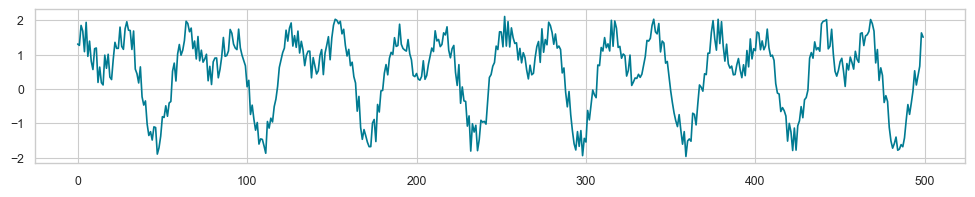

In [4]:
n = 500
x = np.arange(0, n, 1) 
y = np.sin(16*np.pi*x/n) + np.cos(32*np.pi*x/n)
noisy = np.random.rand(n)
y = y + noisy
data_org = y.reshape(-1, 1)

data = data_org
print(data.shape)
plt.rcParams["figure.figsize"] = (12,2)
plt.plot(data)

## Data transformation

	1. ADF :  -4.536893398329214
	2. P-Value :  0.000168561986824234
	3. Num Of Lags :  14


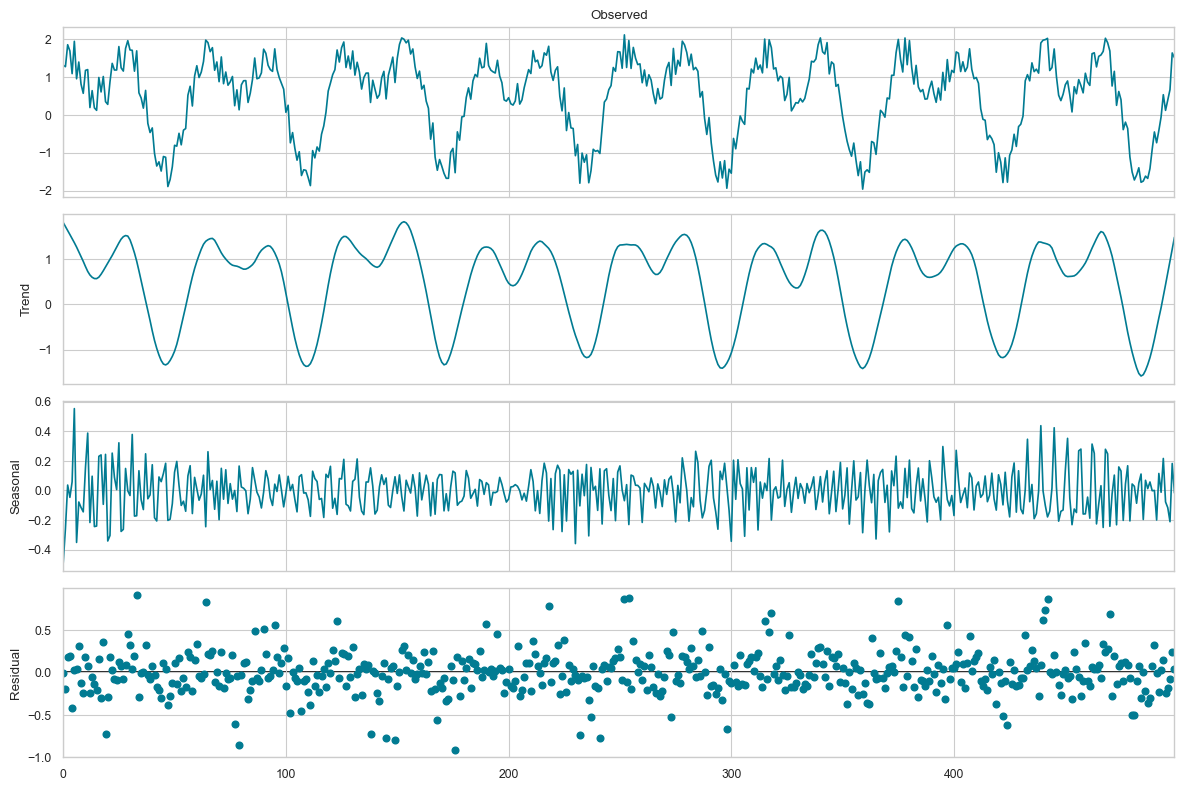

In [5]:
dftest = adfuller(data, autolag = 'AIC')
print("\t1. ADF : ",dftest[0])
print("\t2. P-Value : ", dftest[1])
print("\t3. Num Of Lags : ", dftest[2])
          
result = STL(data, period=6, robust = True).fit()
plt.rcParams["figure.figsize"] = (12,8)
result.plot()
plt.show()
data_cleaned = result.trend.reshape(-1, 1)

## Data normalization

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_trans = scaler.fit_transform(data_cleaned)

## Data splitting and time-series generator

In [7]:
train_size = int(len(data_trans) * 0.80)
test_size = len(data_trans) - train_size
train, test = data_trans[0:train_size,:], data_trans[train_size:len(data_trans),:]

look_back = 10
train_data_gen = TimeseriesGenerator(train, 
                                     train,
                                     length=look_back, 
                                     sampling_rate=1,
                                     stride=1,
                                     batch_size=1
                                    )
test_data_gen = TimeseriesGenerator(test, 
                                    test,
                                    length=look_back, 
                                    sampling_rate=1,
                                    stride=1,
                                    batch_size=1
                                   )

## Training

In [8]:
# model
x = Input(shape=(look_back, 1))
h = LSTM(units=5)(x)   
y = Dense(units=1, activation='sigmoid')(h)
model = Model(inputs=x, outputs=y)
print(model.summary())

# compile model
opt = Adam(learning_rate=0.001)
model.compile(loss='mean_squared_error', optimizer=opt, metrics=['mse', 'mae'])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5)              │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146 (584.00 B)

 Trainable params: 146 (584.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [9]:
model.fit(train_data_gen, epochs=20, shuffle=True)

Epoch 1/20


/Users/giangnguyen/miniconda3/envs/iau-m2/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step - loss: 0.0758 - mae: 0.2411 - mse: 0.0758
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0545 - mae: 0.1886 - mse: 0.0545
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - loss: 0.0381 - mae: 0.1599 - mse: 0.0381
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step - loss: 0.0171 - mae: 0.1110 - mse: 0.0171
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - loss: 0.0099 - mae: 0.0828 - mse: 0.0099
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - loss: 0.0068 - mae: 0.0673 - mse: 0.0068
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step - loss: 0.0055 - mae: 0.0599 - mse: 0.0055
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step - loss: 0.0039 - mae: 0.0508 - mse: 0.0039
Epoch 9/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 0.0032 - mae: 0.0463 - mse: 0.0032
Epoch 10/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 0.0025 - mae: 0.0400 - mse: 0.0025
Epoch 11/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0

In [10]:
model.evaluate(test_data_gen)

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - loss: 8.1541e-04 - mae: 0.0226 - mse: 8.1541e-04


[0.0007848170935176313, 0.0007848170935176313, 0.021426351740956306]

In [11]:
trainPredict = model.predict(train_data_gen)
print(trainPredict.shape)
testPredict = model.predict(test_data_gen)
print(testPredict.shape)

390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step
(390, 1)
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step
(90, 1)


## Invert transformation

In [12]:
trainPredict = scaler.inverse_transform(trainPredict)
testPredict = scaler.inverse_transform(testPredict)

In [13]:
trainY = get_y_from_generator(train_data_gen)
testY = get_y_from_generator(test_data_gen)

(390, 1)
(90, 1)


In [14]:
trainY = scaler.inverse_transform(trainY)
testY = scaler.inverse_transform(testY)

## Model evaluation

In [15]:
trainScore = math.sqrt(mean_squared_error(trainY[:,0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY[:, 0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 0.09 RMSE
Test Score: 0.10 RMSE


## Plotting

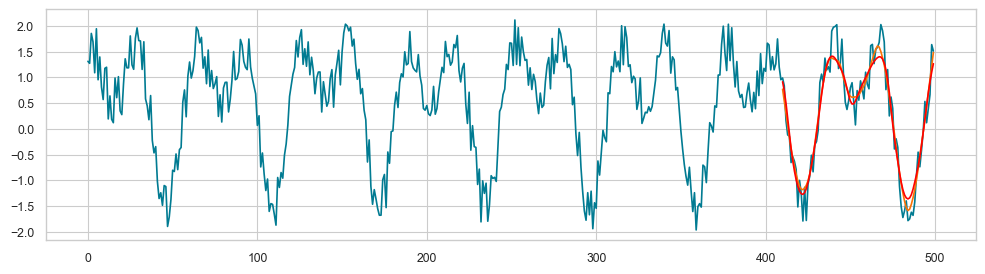

In [16]:
begin = train_size + look_back
end = begin + len(testPredict)

testYPlot = np.empty_like(data_org)
testYPlot[:, :] = np.nan
testYPlot[begin:end, :] = testY

testPredictPlot = np.empty_like(data_org)
testPredictPlot[:, :] = np.nan
testPredictPlot[begin:end, :] = testPredict

# plot baseline and predictions
plt.rcParams["figure.figsize"] = (12,3)
plt.plot(data_org)
plt.plot(testYPlot)
plt.plot(testPredictPlot)
plt.show()